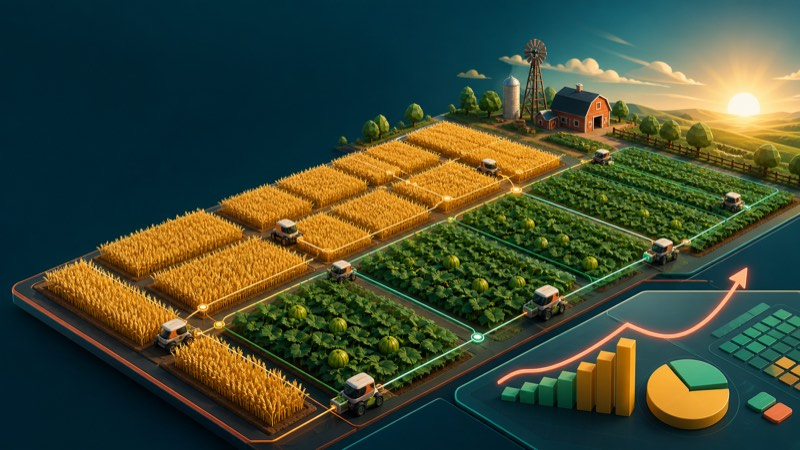

# 🌾 Why Tomatoes Lost: A 60-Game Kaggriculture Agent

The easy baseline won **20/20** local games—and entered the live ladder at **rank 3,789**.

That failure is the useful part of this notebook. Kaggriculture is not a single-player farming problem: crop prices are shared, production creates gluts, and the opponent changes the value of every harvest. We will turn that lesson into a tested mixed-crop agent, compare five policies across both player seats, and export the exact submission file.

> **What you get:** crop economics, a seat-balanced policy tournament, failure analysis, and a self-contained `main.py`.

### Live ladder checkpoint (13 Aug 2026)

| Agent | Public score | Rank | Change |
|---|---:|---:|---:|
| v1 tomato monoculture | 304.0 | 3,789 | baseline |
| v2 tested mixed portfolio | **600.0** | **2,618** | **+1,171 places** |

The first rated checkpoint is progress, not a medal claim. It confirms that the local policy tournament selected a materially stronger ladder agent while leaving a large gap to the medal zone.


In [ ]:
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
COLORS = {'winner': '#0f766e', 'runner': '#f59e0b', 'weak': '#ef4444'}
pd.set_option('display.max_colwidth', 80)


## 1. Start with unit economics—not a favorite crop

The table below uses the competition's default seed costs, base prices, maximum yields, and crop timings. `gross_profit` is deliberately simple: it ignores labor, walking, market impact, and missed watering. That makes it a screening tool, not a strategy.


In [ ]:
crops = pd.DataFrame([
    ('WHEAT', 10, 2, 4, 6, 25, False),
    ('CARROT', 20, 2, 3, 4, 35, False),
    ('TOMATO', 50, 8, 8, 4, 60, True),
    ('STRAWBERRY', 100, 10, 10, 4, 120, True),
    ('MELON', 80, 10, 12, 6, 250, False),
], columns=['crop','seed_cost','first_yield_day','max_yield_day','max_yield','base_price','ongoing'])
crops['gross_revenue'] = crops.max_yield * crops.base_price
crops['gross_profit'] = crops.gross_revenue - crops.seed_cost
crops['gross_profit_per_day'] = (crops.gross_profit / crops.max_yield_day).round(1)
crops.sort_values('gross_profit_per_day', ascending=False)


In [ ]:
plot_df = crops.sort_values('gross_profit_per_day')
fig, ax = plt.subplots(figsize=(10, 4.8))
bars = ax.barh(plot_df.crop, plot_df.gross_profit_per_day,
               color=['#94a3b8' if c != 'MELON' else COLORS['winner'] for c in plot_df.crop])
ax.bar_label(bars, fmt='%.1f', padding=4, fontweight='bold')
ax.set(title='Naive crop screen: melon dominates gross profit per growing day',
       xlabel='Base-price gross profit / max-yield day', ylabel='')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()


### Why the obvious answer still loses

Melon has the best isolated economics, but its market curve punishes oversupply aggressively. A pure-melon agent competes with the opponent for the same early high prices. Wheat adds three things melon cannot: fast opening cash, a separate demand curve, and a four-day endgame crop.

The resulting hypothesis is not “melon is best.” It is:

> **Use melon for season-scale profit, wheat for liquidity and market diversification, and delay expansion until labor can service it.**


## 2. The experiment: five policies, both seats

Every pairing below played three fixed seeds from both player positions: **10 pairings × 3 seeds × 2 seats = 60 full 720-turn games**. Seat balancing matters because simultaneous market orders can otherwise make a tiny first-player advantage look like strategy.

Policies varied only three high-impact choices:

- pure melon vs 40%, 60%, or 80% melon lanes;
- wheat as the complementary crop and final four-day crop;
- expansion on day 4, day 8, or day 12.


In [ ]:
tournament = pd.DataFrame([
    ('60% melon + wheat, expand day 8', 23, 24, 6483),
    ('40% melon + wheat, expand day 4', 18, 24, 3161),
    ('60% melon + wheat, expand day 4', 13, 24, 5388),
    ('Pure melon, expand day 12', 6, 24, -3385),
    ('80% melon + wheat, expand day 4', 0, 24, -11647),
], columns=['policy','wins','games','mean_margin'])
tournament['win_rate'] = tournament.wins / tournament.games
tournament


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
ordered = tournament.sort_values('win_rate')
colors = [COLORS['winner'] if 'day 8' in x else '#94a3b8' for x in ordered.policy]
axes[0].barh(ordered.policy, ordered.win_rate * 100, color=colors)
axes[0].set(title='Round-robin win rate', xlabel='Win rate (%)', ylabel='')
axes[0].axvline(50, color='#334155', ls='--', lw=1)
axes[1].barh(ordered.policy, ordered.mean_margin, color=colors)
axes[1].axvline(0, color='#334155', lw=1)
axes[1].set(title='Mean cash margin across opponents', xlabel='Final cash advantage', ylabel='')
for ax in axes: ax.spines[['top','right']].set_visible(False)
plt.tight_layout()


## 3. What the ablation says

Three conclusions survived the tournament:

1. **Market diversity beats maximum theoretical yield.** The 80%-melon policy went 0/24 despite melon's excellent standalone economics.
2. **Expansion timing is an optimization variable.** Delaying the same 60/40 portfolio from day 4 to day 8 changed it from 13 wins to 23.
3. **Absolute cash is not enough.** A policy must earn cash *relative to an opponent acting on the same market*.

The winning day-8 policy then played 20 more seat-balanced games against the runner-up: **13 wins, mean margin +303.4**. It also completed five games against each official baseline with no runtime errors.


In [ ]:
validation = pd.DataFrame([
    ('Runner-up mixed policy', 20, 13, 303.4, np.nan),
    ('Official starter', 5, 5, 30950.4, 34437.2),
    ('Official random', 5, 5, 33374.8, 33374.8),
], columns=['opponent','games','wins','mean_margin','mean_final_cash'])
validation['win_rate'] = validation.wins / validation.games
validation


## 4. Final agent design

The final policy stays intentionally interpretable:

- **Spatial portfolio:** deterministic 60/40 melon–wheat lanes prevent workers from thrashing between random crop decisions.
- **Calendar:** after day 17, only wheat is planted; after day 25, no seed capital is trapped in crops that cannot finish.
- **Labor:** 7 hands for one field, 12 for two; more workers enter the steep part of the Fibonacci wage curve.
- **Expansion:** unlock field two on day 8 only when at least $1,800 is available.
- **Scheduler:** harvest mature crops, water living crops, dig weeds, then plant; within each priority, assign the nearest task.
- **Market:** sell shed inventory immediately to capture shared pre-glut prices and free the 100-unit shed.

This is a deterministic heuristic agent—not reinforcement learning. That is a feature here: every decision is auditable, cheap to test, and easy to improve from replays.


## 5. Export the exact Kaggle submission

The cell below contains the complete tested agent and writes `main.py`. It uses only the observation dictionary and Python's standard library.


In [ ]:
agent_source = '"""Kaggriculture candidate v3: mixed melon/wheat portfolio."""\n\nCROP_COST = {"MELON": 80, "WHEAT": 10}\nMAX_AGE = {"MELON": 12, "WHEAT": 4}\n\n\ndef _owned_cells(farm):\n    return [\n        (x, y, tile)\n        for y, row in enumerate(farm["tiles"])\n        for x, tile in enumerate(row)\n        if tile != "LOCKED"\n    ]\n\n\ndef _plant_crop(x, y, day):\n    if day > 25:\n        return None\n    if day > 17:\n        return "WHEAT"\n    # Three melon lanes finance the season; two wheat lanes create early cash\n    # and diversify away from melon\'s aggressive shared-market price curve.\n    return "MELON" if (x + 2 * y) % 5 < 3 else "WHEAT"\n\n\ndef _target_hands(fields):\n    return 7 if fields == 1 else 12\n\n\ndef _step_toward(position, target, unit_index):\n    x, y = position\n    tx, ty = target\n    if unit_index % 2 == 0 and x != tx:\n        return ["EAST" if tx > x else "WEST"]\n    if y != ty:\n        return ["SOUTH" if ty > y else "NORTH"]\n    if x != tx:\n        return ["EAST" if tx > x else "WEST"]\n    return ["PASS"]\n\n\ndef _tasks(farm, seed_stock, day):\n    tasks = []\n    for x, y, tile in _owned_cells(farm):\n        if isinstance(tile, dict) and tile.get("kind") == "PLANT":\n            crop = tile.get("crop")\n            age = day - int(tile.get("planted_day", day))\n            mature = age >= MAX_AGE.get(crop, 999) and tile.get("yield_units", 0) > 0\n            if mature:\n                tasks.append((0, x, y, ["HARVEST"]))\n            elif not tile.get("watered_today", False):\n                tasks.append((0, x, y, ["WATER"]))\n        elif isinstance(tile, dict) and tile.get("kind") == "WEED":\n            tasks.append((1, x, y, ["DIG"]))\n        elif tile is None:\n            crop = _plant_crop(x, y, day)\n            if crop and seed_stock.get(crop, 0) > 0:\n                tasks.append((2, x, y, ["PLANT", crop]))\n    return tasks\n\n\ndef _unit_actions(farm, private, day):\n    positions = [farm["farmer"]] + list(farm.get("hands", []))\n    stock = {c: int(private.get("seeds", {}).get(c, 0)) for c in CROP_COST}\n    remaining = _tasks(farm, stock, day)\n    actions = []\n    for unit_index, position in enumerate(positions):\n        if not remaining:\n            actions.append(["PASS"])\n            continue\n        px, py = position\n        usable = [t for t in remaining if t[3][0] != "PLANT" or stock.get(t[3][1], 0) > 0]\n        if not usable:\n            actions.append(["PASS"])\n            continue\n        task = min(usable, key=lambda t: (t[0], abs(t[1]-px)+abs(t[2]-py), t[2], t[1]))\n        remaining.remove(task)\n        _, tx, ty, operation = task\n        if (px, py) == (tx, ty):\n            if operation[0] == "PLANT":\n                stock[operation[1]] -= 1\n            actions.append(operation)\n        else:\n            actions.append(_step_toward((px, py), (tx, ty), unit_index))\n    return actions\n\n\ndef agent(obs):\n    player = int(obs.get("player", 0))\n    farms = obs.get("farms", [])\n    if player >= len(farms):\n        return {"farmer": ["PASS"], "hands": [], "market": []}\n    farm = farms[player]\n    private = obs.get("private", {}) or {}\n    day = int(obs.get("day", 0))\n    hour = int(obs.get("hour", 0))\n    shed = private.get("shed", {}) or {}\n    seeds = private.get("seeds", {}) or {}\n    market = []\n\n    for item, quantity in shed.items():\n        if quantity > 0 and item not in ("GOOSE", "COW", "SHEEP", "FERTILIZER"):\n            market.append(["SELL", item, int(quantity)])\n\n    fields = len(farm.get("unlocked_quadrants", []))\n    target_hands = _target_hands(fields)\n    if hour == 0:\n        market.extend([["HIRE"] for _ in range(max(0, target_hands-len(farm.get("hands", []))))])\n\n    # Wheat\'s first harvest pays for a second 5x5 field without starving the\n    # opening melon portfolio of seed capital.\n    if day >= 8 and fields < 2 and farm["money"] >= 1800:\n        market.append(["BUY_LAND"])\n\n    empty = [(x, y) for x, y, tile in _owned_cells(farm) if tile is None]\n    desired = {"MELON": 0, "WHEAT": 0}\n    for x, y in empty:\n        crop = _plant_crop(x, y, day)\n        if crop:\n            desired[crop] += 1\n\n    reserve = 700 if fields == 1 else 1200\n    cash = max(0, int(farm["money"] - reserve))\n    # Buy the expensive crop first; wheat uses whatever small remainder is left.\n    for crop in ("MELON", "WHEAT"):\n        missing = max(0, desired[crop] - int(seeds.get(crop, 0)))\n        amount = min(missing, cash // CROP_COST[crop])\n        if amount > 0:\n            market.append(["BUY_SEED", crop, amount])\n            cash -= amount * CROP_COST[crop]\n\n    actions = _unit_actions(farm, private, day)\n    return {"farmer": actions[0] if actions else ["PASS"], "hands": actions[1:], "market": market[:10]}\n\n\nif __name__ == "__main__":\n    print("Kaggriculture Agent v3 mixed portfolio")\n'
Path('main.py').write_text(agent_source, encoding='utf-8')
print(f'Wrote main.py ({len(agent_source):,} characters)')

In [ ]:
# Fast structural checks before submitting.
compile(agent_source, 'main.py', 'exec')
assert 'def agent(obs):' in agent_source
assert 'MELON' in agent_source and 'WHEAT' in agent_source
print('✓ Syntax valid  ✓ agent entry point found  ✓ mixed portfolio present')


## 6. Honest limitations—and the next experiments

This agent is a stronger baseline, not a medal guarantee. The public ladder is noisy, only the latest two submissions remain active, and strong opponents may exploit animals, fertilizer, adaptive pricing, or better routing.

The next high-value tests are:

- switch crop ratios using *current* market prices and opponent inventory pressure;
- reserve tasks across turns to reduce worker route oscillation;
- compare two-field crops with a specialized animal policy;
- evaluate against downloaded live replays, not only local heuristics.

The durable lesson is simple: **a green local win rate can hide a weak opponent set.** Make the first submission early, let the ladder falsify your assumptions, then turn that failure into a controlled experiment.

If this experiment saved you a few submissions, I would love to hear which policy you test next. 🌱
